# IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# LOAD DATASET

In [2]:
df = pd.read_excel(r"C:\Users\lenovo\Downloads\route_prediction_3000_rows_dataset.xlsx")
df

C:\Users\lenovo\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\lenovo\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Conditional Formatting extension is not supported and will be removed
  for idx, row in parser.parse():


,Route_ID,Date,Source,Destination,Distance_km,Vehicle_Type,Route_Type,Day_of_Week,Time_of_Day,Peak_Hour,...,Accident,Road_Closure,Alternative_Routes,Speed_Limit_kmph,Avg_Speed_kmph,Estimated_Time_min,Delay_Minutes,Fuel_Consumption_L,Predicted_Time_min,Optimal_Route
0,R0001,2025-01-13,Madhavaram,OMR,5.6,Car,Highway,Monday,Evening,Yes,...,No,No,2,80,42.3,4.2,21.5,0.50,29.4,No
1,R0002,2025-04-23,OMR,Anna Nagar,18.2,Bike,Service Road,Wednesday,Afternoon,No,...,No,No,2,35,20.2,31.2,11.9,0.70,66.0,No
2,R0003,2025-06-26,Tambaram,Guindy,46.3,Van,Mixed,Thursday,Evening,No,...,No,No,1,60,19.9,46.3,21.6,6.49,161.2,No
3,R0004,2025-04-30,Anna Nagar,OMR,38.2,Car,City Road,Wednesday,Night,No,...,No,No,2,50,25.3,45.8,15.3,3.23,105.9,No
4,R0005,2025-07-14,Velachery,Adyar,45.9,Bus,City Road,Monday,Morning,No,...,No,No,4,50,25.9,55.1,10.2,10.96,116.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,R2996,2025-03-17,Tambaram,T Nagar,25.0,Car,City Road,Monday,Evening,No,...,No,No,3,50,44.2,30.0,0.0,1.88,33.9,Yes
2996,R2997,2025-06-02,Anna Nagar,T Nagar,43.5,Car,Highway,Monday,Morning,Yes,...,No,No,2,80,34.6,32.6,26.0,3.97,101.4,No
2997,R2998,2025-12-11,OMR,Madhavaram,15.9,Bike,Mixed,Thursday,Morning,Yes,...,No,No,2,60,34.9,15.9,26.7,0.68,54.0,No
2998,R2999,2025-09-06,Tambaram,Madhavaram,28.9,Truck,City Road,Saturday,Night,No,...,No,No,3,50,28.6,34.7,11.6,9.51,72.2,No


In [3]:
print(df.head())

  Route_ID        Date      Source Destination  Distance_km Vehicle_Type  \
0    R0001  2025-01-13  Madhavaram         OMR          5.6          Car   
1    R0002  2025-04-23         OMR  Anna Nagar         18.2         Bike   
2    R0003  2025-06-26    Tambaram      Guindy         46.3          Van   
3    R0004  2025-04-30  Anna Nagar         OMR         38.2          Car   
4    R0005  2025-07-14   Velachery       Adyar         45.9          Bus   

     Route_Type Day_of_Week Time_of_Day Peak_Hour  ... Accident Road_Closure  \
0       Highway      Monday     Evening       Yes  ...       No           No   
1  Service Road   Wednesday   Afternoon        No  ...       No           No   
2         Mixed    Thursday     Evening        No  ...       No           No   
3     City Road   Wednesday       Night        No  ...       No           No   
4     City Road      Monday     Morning        No  ...       No           No   

  Alternative_Routes Speed_Limit_kmph Avg_Speed_kmph  Estimate

In [4]:
print(df.shape)

(3000, 23)


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Route_ID            3000 non-null   object 
 1   Date                3000 non-null   object 
 2   Source              3000 non-null   object 
 3   Destination         3000 non-null   object 
 4   Distance_km         3000 non-null   float64
 5   Vehicle_Type        3000 non-null   object 
 6   Route_Type          3000 non-null   object 
 7   Day_of_Week         3000 non-null   object 
 8   Time_of_Day         3000 non-null   object 
 9   Peak_Hour           3000 non-null   object 
 10  Traffic_Level       3000 non-null   object 
 11  Weather_Condition   3000 non-null   object 
 12  Road_Condition      3000 non-null   object 
 13  Accident            3000 non-null   object 
 14  Road_Closure        3000 non-null   object 
 15  Alternative_Routes  3000 non-null   int64  
 16  Speed_

# EXPLORATORY DATA ANALYSIS (EDA)

## MISSING VALUES

In [6]:
print(df.isnull().sum())

Route_ID              0
Date                  0
Source                0
Destination           0
Distance_km           0
Vehicle_Type          0
Route_Type            0
Day_of_Week           0
Time_of_Day           0
Peak_Hour             0
Traffic_Level         0
Weather_Condition     0
Road_Condition        0
Accident              0
Road_Closure          0
Alternative_Routes    0
Speed_Limit_kmph      0
Avg_Speed_kmph        0
Estimated_Time_min    0
Delay_Minutes         0
Fuel_Consumption_L    0
Predicted_Time_min    0
Optimal_Route         0
dtype: int64


## SUMMARY STATISTICS

In [7]:
print(df.describe())

       Distance_km  Alternative_Routes  Speed_Limit_kmph  Avg_Speed_kmph  \
count  3000.000000         3000.000000       3000.000000     3000.000000   
mean     29.559567            1.935333         59.498333       27.772267   
std      14.653219            1.102220         13.268334       13.030648   
min       4.100000            0.000000         35.000000        8.000000   
25%      17.000000            1.000000         50.000000       18.200000   
50%      29.000000            2.000000         60.000000       25.900000   
75%      42.300000            3.000000         80.000000       35.800000   
max      55.000000            5.000000         80.000000       77.400000   

       Estimated_Time_min  Delay_Minutes  Fuel_Consumption_L  \
count         3000.000000    3000.000000         3000.000000   
mean            31.244600      21.036700            5.140430   
std             17.186238      14.261813            4.626273   
min              3.100000       0.000000            0.15000

## DISTRIBUTION OF TRAVEL TIME

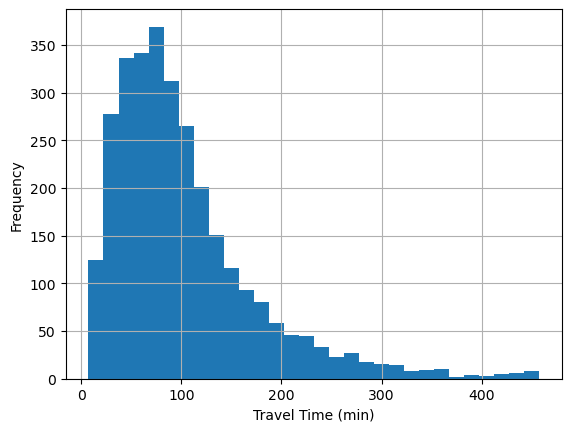

In [8]:
df['Predicted_Time_min'].hist(bins=30)
plt.xlabel('Travel Time (min)')
plt.ylabel('Frequency')
plt.show()

## CORRELATION (numeric only)

In [9]:
numeric_df = df.select_dtypes(include=np.number)
print(numeric_df.corr()['Predicted_Time_min'].sort_values(ascending=False))

Predicted_Time_min    1.000000
Estimated_Time_min    0.621990
Delay_Minutes         0.617750
Fuel_Consumption_L    0.590602
Distance_km           0.558266
Alternative_Routes   -0.011019
Speed_Limit_kmph     -0.223865
Avg_Speed_kmph       -0.646418
Name: Predicted_Time_min, dtype: float64


# FEATURE ENGINEERING

## CONVERT DATE INTO USEFUL FEATURES

In [10]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

df.drop('Date', axis=1, inplace=True)

# DEFINE FEATURES AND TARGET

In [11]:
X = df.drop('Predicted_Time_min', axis=1)
y = df['Predicted_Time_min']

# IDENTIFY COLUMN TYPES

In [12]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print('Categorical:', categorical_cols)
print('Numerical:', numerical_cols)

Categorical: ['Route_ID', 'Source', 'Destination', 'Vehicle_Type', 'Route_Type', 'Day_of_Week', 'Time_of_Day', 'Peak_Hour', 'Traffic_Level', 'Weather_Condition', 'Road_Condition', 'Accident', 'Road_Closure', 'Optimal_Route']
Numerical: ['Distance_km', 'Alternative_Routes', 'Speed_Limit_kmph', 'Avg_Speed_kmph', 'Estimated_Time_min', 'Delay_Minutes', 'Fuel_Consumption_L', 'Day', 'Month', 'DayOfWeek']


# PREPROCESSING PIPELINE

In [13]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median'))])

In [14]:
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [15]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)])

# SPLIT DATASET

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

# BUILD MACHINE LEARNING PIPELINE

In [17]:
model = Pipeline([('preprocessor', preprocessor), ('regressor', RandomForestRegressor( n_estimators=200, random_state=42, n_jobs=-1))])

# TRAIN MODEL

In [18]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Distance_km',
                                                   'Alternative_Routes',
                                                   'Speed_Limit_kmph',
                                                   'Avg_Speed_kmph',
                                                   'Estimated_Time_min',
                                                   'Delay_Minutes',
                                                   'Fuel_Consumption_L', 'Day',
                                                   'Month', 'DayOfWeek']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Route_ID', 'Source',
                                                   'Destination',
                                                   'Vehicle_Type', 'Route_Type',
                                                   'Day_of_Week', 'Time_of_Day',
                                                   'Peak_Hour', 'Traffic_Level',
                                                   'Weather_Condition',
                                                   'Road_Condition', 'Accident',
                                                   'Road_Closure',
                                                   'Optimal_Route'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

# MAKE PREDICTIONS

In [19]:
y_pred = model.predict(X_test)

# EVALUATE MODEL

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 3.3607058333333324
RMSE: 5.296962030140478
R2 Score: 0.9946513254545527


# SAVE TRAINED MODEL

In [21]:
joblib.dump(model, 'travel_time_model.pkl')

['travel_time_model.pkl']

# LOAD SAVED MODEL

In [22]:
loaded_model = joblib.load('travel_time_model.pkl')

In [23]:
X.columns

Index(['Route_ID', 'Source', 'Destination', 'Distance_km', 'Vehicle_Type',
       'Route_Type', 'Day_of_Week', 'Time_of_Day', 'Peak_Hour',
       'Traffic_Level', 'Weather_Condition', 'Road_Condition', 'Accident',
       'Road_Closure', 'Alternative_Routes', 'Speed_Limit_kmph',
       'Avg_Speed_kmph', 'Estimated_Time_min', 'Delay_Minutes',
       'Fuel_Consumption_L', 'Optimal_Route', 'Day', 'Month', 'DayOfWeek'],
      dtype='object')

In [24]:
X.iloc[0]

Route_ID                   R0001
Source                Madhavaram
Destination                  OMR
Distance_km                  5.6
Vehicle_Type                 Car
Route_Type               Highway
Day_of_Week               Monday
Time_of_Day              Evening
Peak_Hour                    Yes
Traffic_Level             Medium
Weather_Condition          Clear
Road_Condition          Moderate
Accident                      No
Road_Closure                  No
Alternative_Routes             2
Speed_Limit_kmph              80
Avg_Speed_kmph              42.3
Estimated_Time_min           4.2
Delay_Minutes               21.5
Fuel_Consumption_L           0.5
Optimal_Route                 No
Day                           13
Month                          1
DayOfWeek                      0
Name: 0, dtype: object

# PREDICT NEW ROUTE TIME

In [25]:
sample = pd.DataFrame({
    'Source': ['Chennai'],
    'Destination': ['Bangalore'],
    'Distance_km': [350],
    'Traffic_Level': ['High'],
    'Weather': ['Rainy'],
    'Average_Speed_kmph': [60],
    'Road_Type': ['Highway'],
    'Delay_min': [25],
    'Fuel_Consumption_L': [28],
    'Optimal_Route': ['Yes'],
    'Day': [10],
    'Month': [5],
    'DayOfWeek': [2]
})

import pandas as pd

# Create sample DataFrame using the given values
sample = pd.DataFrame({
    'Route_ID': ['R0001'],
    'Source': ['Chennai'],
    'Destination': ['Bangalore'],
    'Distance_km': [350],
    'Vehicle_Type': ['Car'],
    'Route_Type': ['Highway'],
    'Day_of_Week': ['Monday'],
    'Time_of_Day': ['Evening'],
    'Peak_Hour': ['Yes'],
    'Traffic_Level': ['Medium'],
    'Weather_Condition': ['Clear'],
    'Road_Condition': ['Moderate'],
    'Accident': ['No'],
    'Road_Closure': ['No'],
    'Alternative_Routes': [2],
    'Speed_Limit_kmph': [80],
    'Avg_Speed_kmph': [42.3],
    'Estimated_Time_min': [4.2],
    'Delay_Minutes': [21.5],
    'Fuel_Consumption_L': [0.5],
    'Optimal_Route': ['No'],
    'Day': [13],
    'Month': [1],
    'DayOfWeek': [0]
})

# Display the sample row
# print(sample)

prediction = loaded_model.predict(sample)
print('Predicted Travel Time:', prediction[0], 'minutes')

Predicted Travel Time: 82.39800000000012 minutes


In [26]:
df.columns

Index(['Route_ID', 'Source', 'Destination', 'Distance_km', 'Vehicle_Type',
       'Route_Type', 'Day_of_Week', 'Time_of_Day', 'Peak_Hour',
       'Traffic_Level', 'Weather_Condition', 'Road_Condition', 'Accident',
       'Road_Closure', 'Alternative_Routes', 'Speed_Limit_kmph',
       'Avg_Speed_kmph', 'Estimated_Time_min', 'Delay_Minutes',
       'Fuel_Consumption_L', 'Predicted_Time_min', 'Optimal_Route', 'Day',
       'Month', 'DayOfWeek'],
      dtype='object')

In [27]:
print('Optimal_Route' in df.columns)

True


# CLASSIFICATION MODEL FOR OPTIMAL ROUTE

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_cls = df.drop('Optimal_Route', axis=1)
y_cls = df['Optimal_Route']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# Identify categorical and numerical columns from X_cls
categorical_cols = X_cls.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X_cls.select_dtypes(exclude=['object']).columns.tolist()

# Numeric preprocessing
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Recreate preprocessor using X_cls columns only
preprocessor_cls = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

classifier = Pipeline([
    ('preprocessor', preprocessor_cls),
    ('clf', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.955
              precision    recall  f1-score   support

          No       0.95      1.00      0.98       555
         Yes       1.00      0.40      0.57        45

    accuracy                           0.95       600
   macro avg       0.98      0.70      0.77       600
weighted avg       0.96      0.95      0.95       600



# FEATURE IMPORTANCE

In [29]:
rf = model.named_steps['regressor']
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance.head(20))

                           Feature  Importance
3              num__Avg_Speed_kmph    0.574488
0                 num__Distance_km    0.346043
4          num__Estimated_Time_min    0.041200
5               num__Delay_Minutes    0.030368
6          num__Fuel_Consumption_L    0.001696
7                         num__Day    0.000633
8                       num__Month    0.000488
9                   num__DayOfWeek    0.000312
1          num__Alternative_Routes    0.000278
2459  cat__Traffic_Level_Very High    0.000155
2456       cat__Traffic_Level_High    0.000141
2463   cat__Weather_Condition_Rain    0.000116
2460  cat__Weather_Condition_Clear    0.000113
2454             cat__Peak_Hour_No    0.000111
2472         cat__Optimal_Route_No    0.000106
2451      cat__Time_of_Day_Evening    0.000106
2458     cat__Traffic_Level_Medium    0.000103
2473        cat__Optimal_Route_Yes    0.000102
2            num__Speed_Limit_kmph    0.000100
2455            cat__Peak_Hour_Yes    0.000100


# STREAMLIT WEB APP

In [30]:
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('travel_time_model.pkl')

st.title('Route Prediction System')

source = st.text_input('Source', 'Chennai')
destination = st.text_input('Destination', 'Bangalore')
distance = st.number_input('Distance (km)', 1.0, 5000.0, 350.0)
traffic = st.selectbox('Traffic Level', ['Low', 'Medium', 'High'])
weather = st.selectbox('Weather', ['Clear', 'Rainy', 'Foggy'])
speed = st.number_input('Average Speed (km/h)', 1.0, 200.0, 60.0)
road_type = st.selectbox('Road Type', ['Highway', 'City', 'Rural'])
delay = st.number_input('Delay (min)', 0.0, 500.0, 25.0)
fuel = st.number_input('Fuel Consumption (L)', 0.0, 1000.0, 28.0)
optimal = st.selectbox('Optimal Route', ['Yes', 'No'])

if st.button('Predict'):
    input_df = pd.DataFrame({
        'Source': [source],
        'Destination': [destination],
        'Distance_km': [distance],
        'Traffic_Level': [traffic],
        'Weather': [weather],
        'Average_Speed_kmph': [speed],
        'Road_Type': [road_type],
        'Delay_min': [delay],
        'Fuel_Consumption_L': [fuel],
        'Optimal_Route': [optimal],
        'Day': [1],
        'Month': [1],
        'DayOfWeek': [0]
    })

    pred = model.predict(input_df)[0]
    st.success(f'Predicted Travel Time: {pred:.2f} minutes')

2026-06-21 08:20:37.710 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.660 
  command:

    streamlit run C:\Users\lenovo\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-06-21 08:20:38.661 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.662 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.666 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.667 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-21 08:20:38.668 Session state does not